In [1]:
import sys
import glob
import torch

sys.path.append('../utils/')
sys.path.append('../src/model/')

sys.path.append("/om2/user/bjmedina/auditory-memory/memory/")

from utils.plotting import plot_dprime_by_isi, plot_itemwise_split_half_scatter_df, ensure_dir
from utils.dprime import recompute_dprime_by_isi_per_subject
from utils.reliability import compute_itemwise_split_half_reliability

import DistanceMemoryModel
import encoders

sys.path.append('/om2/user/bjmedina/')

from chexture_choolbox.auditorytexture.statistics_sets import (
    STAT_SET_FULL_MCDERMOTTSIMONCELLI as statistics_dict
)
from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params

import json
import glob
import sys
import os

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from scipy.stats import norm
from collections import defaultdict

def compute_dprime(hit_rate, fa_rate):
    hit_rate = np.clip(hit_rate, 0.0001, 1 - 0.0001)
    fa_rate = np.clip(fa_rate, 0.0001, 1 - 0.0001)
    return norm.ppf(hit_rate) - norm.ppf(fa_rate)

def recompute_dprime_by_isi(exps, criterion=1):
    hit_counts = defaultdict(int)
    fa_counts  = defaultdict(int)
    signal_counts = defaultdict(int)
    noise_counts  = defaultdict(int)

    for df in exps:
        seen_yt_ids = {}
        yt_ids = df['yt_id'].tolist()
        responses = df['response'].tolist()
        repeats = df['repeat'].tolist()


        for i, (yt, resp, repeat) in enumerate(zip(yt_ids, responses, repeats )):
            if pd.isna(resp) or pd.isna(yt):
                continue

            is_yes = int(int(resp) > criterion)

            if repeat == 'true':
                j = yt_ids[:i].index(yt)
                isi = i - j - 1

                if isi not in [-1,0,1,2,3, 4, 8, 16, 32, 64]:
                    continue

                #print(j, i, isi)
                #print(yt_ids[j], yt)
                signal_counts[isi] += 1
                hit_counts[isi] += is_yes
            elif repeat == 'false':
                noise_counts[-1] += 1  # ISI=-1 for noise trials
                fa_counts[-1] += is_yes

                #seen_yt_ids[yt] = i  # store first appearance

        #print("--")

    # Build results
    results = []
    all_isi_vals = sorted(set(signal_counts) | set(noise_counts))
    for isi in all_isi_vals:
        hits = hit_counts[isi]
        fas  = fa_counts[-1]
        n_signal = signal_counts[isi]
        n_noise  = noise_counts[-1]

        hit_rate = hits / n_signal if n_signal > 0 else np.nan
        fa_rate  = fas  / n_noise  if n_noise  > 0 else np.nan
        dprime_val = compute_dprime(hit_rate, fa_rate) #if np.isfinite(hit_rate) and np.isfinite(fa_rate) else np.nan

        results.append({
            'isi': isi,
            'hits': hits,
            'false_alarms': fas,
            'n_signal': n_signal,
            'n_noise': n_noise,
            'hit_rate': hit_rate,
            'fa_rate': fa_rate,
            'd_prime': dprime_val
        })

    return pd.DataFrame(results).sort_values(by='isi')


def recompute_dprime_by_isi_per_subject(exps, criterion=1):
    allowed_isi = {-1, 0, 1, 2, 3, 4, 8, 16, 32, 64}
    all_results = []

    for subj_idx, df in enumerate(exps):
        hit_counts = defaultdict(int)
        fa_counts  = defaultdict(int)
        signal_counts = defaultdict(int)
        noise_counts  = defaultdict(int)

        yt_ids = df['yt_id'].tolist()
        responses = df['response'].tolist()
        repeats = df['repeat'].tolist()

        for i, (yt, resp, repeat) in enumerate(zip(yt_ids, responses, repeats)):
            if pd.isna(resp) or pd.isna(yt):
                continue

            is_yes = int(int(resp) > criterion)

            if repeat == 'true':
                try:
                    j = yt_ids[:i].index(yt)
                    isi = i - j - 1
                except ValueError:
                    continue  # yt not found in earlier trials

                if isi not in allowed_isi:
                    continue

                signal_counts[isi] += 1
                hit_counts[isi] += is_yes

            elif repeat == 'false':
                isi = -1
                noise_counts[isi] += 1
                fa_counts[isi] += is_yes

        # Aggregate per-ISI results for this subject
        for isi in sorted(signal_counts.keys() | noise_counts.keys()):
            n_signal = signal_counts[isi]
            n_noise  = noise_counts.get(-1, 0)  # all noise trials pooled under -1
            hits = hit_counts[isi]
            fas  = fa_counts.get(-1, 0)

            hit_rate = hits / n_signal if n_signal > 0 else np.nan
            fa_rate  = fas  / n_noise  if n_noise  > 0 else np.nan
            d_prime = compute_dprime(hit_rate, fa_rate) if np.isfinite(hit_rate) and np.isfinite(fa_rate) else np.nan

            all_results.append({
                'subject': subj_idx,
                'isi': isi,
                'hits': hits,
                'false_alarms': fas,
                'n_signal': n_signal,
                'n_noise': n_noise,
                'hit_rate': hit_rate,
                'fa_rate': fa_rate,
                'd_prime': d_prime
            })

    return pd.DataFrame(all_results).sort_values(by=['subject', 'isi'])


def load_results(results_dir, isi_pow=2, min_trials=120, skip_len60=True):
    """Load and filter experiment result CSVs."""
    files = sorted(
        [f for f in os.listdir(results_dir) if f.endswith(".csv")],
        key=lambda fn: os.path.getctime(os.path.join(results_dir, fn))
    )
    exps, seqs, fnames = [], [], []
    for fn in files:
        df = pd.read_csv(os.path.join(results_dir, fn))
        main = df[df.stim_type == "main"]
        seq_file = main.sequence_file.iloc[0].split("/")[-1]
        if len(main) < min_trials: continue
        if "tol0" in seq_file: continue
        exps.append(main); seqs.append(seq_file); fnames.append(fn)
    return exps, seqs, fnames

def remove_sequences_with_len60(seq_dir):
    """Remove entries containing 'len60' from unused.json and used.json."""
    for sub in ("unused", "used"):
        path = os.path.join(seq_dir, sub, f"{sub}.json")
        data = json.load(open(path))
        filtered = [f for f in data if "len60" not in f]
        json.dump(sorted(filtered), open(path, "w"), indent=2)

def move_sequences_to_used(seq_dir, seqs_used):
    """Move used sequence filenames from unused.json to used.json."""
    u_path = os.path.join(seq_dir, "unused", "unused.json")
    z_path = os.path.join(seq_dir, "used",   "used.json")
    unused = json.load(open(u_path)); used = json.load(open(z_path))
    seqs = [os.path.basename(s) for s in seqs_used]
    new_unused = [s for s in unused if s not in seqs]
    new_used = sorted(set(used + seqs))
    json.dump(sorted(new_unused), open(u_path, "w"), indent=2)
    json.dump(new_used,         open(z_path, "w"), indent=2)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
# grabbing example list of sound
sounds_list = glob.glob("/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_p1/*wav")
texture_list = sounds_list

ALL_SOUNDS = glob.glob("/om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_*/*wav")
print(len(ALL_SOUNDS))

cuda
2008997


# running encoders

In [7]:
texture_model = encoders.AudioTextureEncoder(
    statistics_dict=statistics_dict,
    model_params=model_params,
    sr=20000,
    rms_level=0.05,
    duration=2.0,
    device=device
)

In [8]:
zscore_projector = encoders.ZScoreSpace(texture_model, device=device)
zscore_projector.fit(texture_list)

In [9]:
projector = encoders.PCASpace(zscore_projector, n_components=800)

# Fit on example_trials
projector.fit(ALL_SOUNDS[:5000])

# Project those same trials or new ones
coords = projector.transform(texture_list)

Skipping /om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_0/YT_-1hPNpfM9p4.wav: Sound too short after resampling: 24280 < 40000
Skipping /om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_0/YT_-3TA9Fns4rA.wav: Sound too short after resampling: 0 < 40000


In [10]:
# projector = encoders.PCASpace(texture_model, n_components=None)  # or use encoder output dim explicitly
# projector.fit(texture_list)

# dim = (projector.pca.explained_variance_ratio_.cumsum() > 0.9).tolist().index(True)

In [11]:
# for the 'encoding_model' -- any encoder would do.
# in this case, AudioTextureEncoder is the auditory texture model. that works fine
# 

memory_model = DistanceMemoryModel.DistanceMemoryModel(
    encoding_model=projector,
    noise_variance=0.1,
    criterion=10,
    device='cuda'
)

memory_model.clear_memory()

example_trials = [sounds_list[0],
                  sounds_list[1],
                  sounds_list[2],
                  sounds_list[3],
                  sounds_list[0],
                  sounds_list[1]]

for j, path in enumerate(example_trials):
    decision = memory_model(path)
    true_answer = 'YES' if example_trials[j] in example_trials[:j] else 'NO'
    print(f"{path.split('/')[-1]} ==> Model {'YES' if decision.item() else 'NO'}, True {true_answer}")

mem_stim_34.wav ==> Model NO, True NO
mem_stim_136.wav ==> Model NO, True NO
mem_stim_99.wav ==> Model NO, True NO
mem_stim_48.wav ==> Model NO, True NO
mem_stim_34.wav ==> Model YES, True YES
mem_stim_136.wav ==> Model YES, True YES


Animation saved to ../movies/tests/distance-model/ex.gif


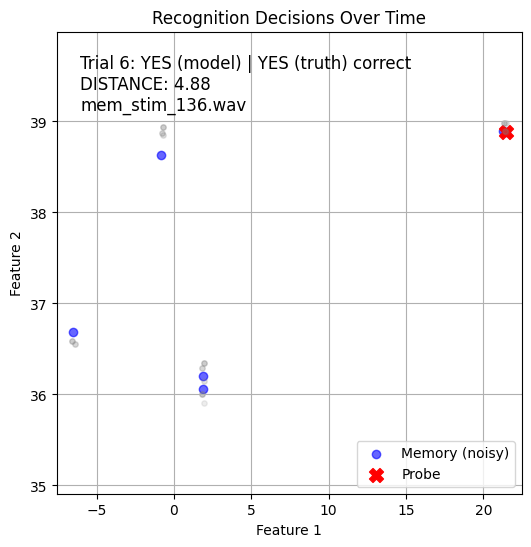

In [12]:
memory_model.animate_trials(save_path = "../movies/tests/distance-model/ex.gif")

In [13]:
import numpy as np
from typing import Callable, List, Dict



In [14]:
tasks = ["ind-nature-len120" ,"global-music-len120", "atexts-len120", "nhs-region-len120"]
which_task = tasks[2] # "global-music-len120", "atexts-len120" "nhs-region-len120"

base_path = "/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{}/sequences/isi_16/len120/"

seqs_paths = {"ind-nature-len120": "mem_exp_ind-nature_2025", 
              "global-music-len120": "global-music-2025-n_80",
              "atexts-len120": "mem_exp_atexts_2025",
              "nhs-region-len120": "nhs-region-n_80"}

hr_task_name = {"ind-nature-len120": "Industrial and Nature", 
              "global-music-len120": "Globalized Music",
              "atexts-len120": "Auditory Textures",
              "nhs-region-len120": " 'Natural History of Song' "}

exps, seqs, fnames = load_results(f"/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/isi_16/{which_task}")
move_sequences_to_used(base_path.format(seqs_paths[which_task]), seqs)


In [15]:
from sklearn.metrics import mean_squared_error

# Your experiment structure (list of stimulus filepaths for each run)
experiment_list = []
for exp in exps:
    list_to_add = []
    for stim in exp.stimulus.tolist():
        edited_stim_name = "/mindhive/mcdermott/www/" + "/".join(stim.split("/")[3:])
        list_to_add.append(edited_stim_name)
    experiment_list.append(list_to_add)


# Human performance (e.g., hit rate per experiment)
#human_scores = [0.82, 0.76, 0.91]

In [16]:
# Run experiment

model_dfs = []

for experiment in experiment_list:
    df = memory_model.do_experiment(experiment, yt_ids=None, verbose=False)
    # Wrap in a list to simulate a list of subject data
    model_dfs.append(df)

    memory_model.clear_memory()
#break


# for idx in range(len(df.response.tolist())):
#     if df.repeat.tolist()[idx] == 'true':
#         print(type(df.response.tolist()[idx]), df.repeat.tolist()[idx], df.yt_id.tolist()[idx], df.isi.tolist()[idx])

In [17]:
def get_dprime_by_isi(df_per_subject, return_sem=False, return_subjects=False):
    """
    Compute mean d-prime per ISI across subjects, excluding ISI = -1 (lures).

    Args:
        df_per_subject (pd.DataFrame): Output from recompute_dprime_by_isi_per_subject.
        return_sem (bool): Whether to return standard error of the mean.
        return_subjects (bool): Whether to return per-subject d-primes too.

    Returns:
        pd.DataFrame or dict:
            If return_sem=False:
                DataFrame with columns ['isi', 'd_prime']
            If return_sem=True:
                DataFrame with columns ['isi', 'd_prime', 'sem']
            If return_subjects=True:
                Returns a dict with:
                    'summary': summary DataFrame as above,
                    'per_subject': filtered per-subject df
    """
    df_filtered = df_per_subject[df_per_subject["isi"] > -1]

    grouped = df_filtered.groupby("isi")["d_prime"]
    result_df = grouped.mean().reset_index(name="d_prime")

    if return_sem:
        result_df["sem"] = grouped.sem().values

    if return_subjects:
        return {
            "summary": result_df,
            "per_subject": df_filtered.copy()
        }

    return result_df.d_prime.tolist()
    
x = recompute_dprime_by_isi_per_subject(model_dfs, criterion=0)
print(get_dprime_by_isi(x))
# print(x.d_prime.tolist())
# grouped = x.groupby("isi")["d_prime"]
# mean_d = x.mean()
# plot_dprime_by_isi(x, stimulus_set=hr_task_name[which_task], save_path=None);

[7.438032970911388, 0.0]


In [18]:
from utils.loading import load_results, load_results_with_isi0_exclusion, load_results_with_isi0_dprime_exclusion, move_sequences_to_used, load_results_with_exclusion

exps, seqs, fnames = load_results_with_exclusion(f"/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/isi_16/{which_task}",
                                                    min_dprime=2,
                                                    min_trials=120,
                                                    skip_len60=True,
                                                    verbose=False,
                                                    return_skipped=False)



move_sequences_to_used(base_path.format(seqs_paths[which_task]), seqs)

print("Number of participants used in analysis:", len(exps))


safe_name = which_task.lower().replace(" ", "_")  # e.g., "globalized_music"
save_dir = os.path.join("/om2/user/bjmedina/auditory-memory/memory/figures/human-results/isi-16-only", safe_name)

ensure_dir(save_dir)
print(save_dir)

human_results = recompute_dprime_by_isi_per_subject(exps)
human_sensitivity = get_dprime_by_isi(human_results)


[3wwdmsyqfc4.csv] d' = 3.97 (HR=1.00, FAR=0.40)
[7jogrkbp84y.csv] d' = 0.00 (HR=0.60, FAR=0.60)
[x2u1rnl6jry.csv] d' = 3.47 (HR=1.00, FAR=0.60)
[wj0a6qjnn25.csv] d' = 2.88 (HR=1.00, FAR=0.80)
[1dqenpvpfbn.csv] d' = 3.97 (HR=1.00, FAR=0.40)
[nbgjl1qv11s.csv] d' = 3.47 (HR=1.00, FAR=0.60)
[57bou300szv.csv] d' = 3.97 (HR=1.00, FAR=0.40)
[prp17n1tkt9.csv] d' = -2.88 (HR=0.80, FAR=1.00)
[ospmoysz4bs.csv] d' = 3.47 (HR=1.00, FAR=0.60)
[hfnot2lwmcf.csv] d' = 2.88 (HR=1.00, FAR=0.80)
[fb6k9ozgjrt.csv] d' = 3.97 (HR=1.00, FAR=0.40)
[dmpvasordex.csv] d' = 3.47 (HR=1.00, FAR=0.60)
[m43hv0vduja.csv] d' = 4.56 (HR=1.00, FAR=0.20)
[gp06nr5fdvt.csv] d' = 0.00 (HR=1.00, FAR=1.00)
[w42gcgbetat.csv] d' = 3.97 (HR=1.00, FAR=0.40)
[lxbdvdvzyed.csv] d' = 4.56 (HR=1.00, FAR=0.20)
[su4y3ecm70b.csv] d' = 4.56 (HR=1.00, FAR=0.20)
[ucl3fo5l4nk.csv] d' = 3.97 (HR=1.00, FAR=0.40)
[3k986dfw0e4.csv] d' = 3.47 (HR=1.00, FAR=0.60)
[w4nnqxpetfp.csv] d' = 0.00 (HR=0.80, FAR=0.80)
[zhgyzwna4g9.csv] d' = 3.47 (HR=1.00, F

In [19]:
# from scipy.optimize import minimize

# def objective_fn(param_array):
#     params = {"noise_variance": param_array[0], "criterion": param_array[1]}
#     return -evaluate_model_fit(params, texture_model, experiment_list, human_scores, mean_squared_error)

# result = minimize(objective_fn, x0=[0.0, ], bounds=[(0, 5.0), (0.0, 100.0)])
# print("Best params:", result.x)

In [20]:
# get_dprime_by_isi(x).d_prime.tolist()

In [21]:
# x0

In [30]:
# from typing import Dict, List
import numpy as np
from dprime import recompute_dprime_by_isi_per_subject
from DistanceMemoryModel import DistanceMemoryModel  # adjust import if needed
from scipy.optimize import minimize

def evaluate_model_dprime_fit(
    memory_model,
    param_dict: Dict[str, float],
    encoding_model,
    experiment_list: List[Dict[str, List[str]]],
    human_sensitivity: np.ndarray,
    device: str = "cpu",
    verbose: bool = False,
) -> float:
    """
    Evaluate model fit to human data by computing MSE between model and human d-primes.

    Args:
        param_dict (dict): Parameters for the memory model.
        encoding_model: A callable encoder.
        experiment_list (list): Each item is a dict with 'stimuli' and 'yt_ids' (same length).
        human_sensitivity (np.ndarray): Ground truth human d-primes, per ISI.
        device (str): Device string.
        verbose (bool): Print status.

    Returns:
        float: Mean squared error between model and human d-primes.
    """
    all_dfs = []

    for i, exp in enumerate(experiment_list):
        model = memory_model(
            encoding_model=encoding_model,
            noise_variance=param_dict.get("noise_variance", 1.0),
            criterion=param_dict.get("criterion", 0.5),
            device=device
        )
        df = model.do_experiment(exp, yt_ids=None, verbose=False)
        all_dfs.append(df)

        if verbose and i % 1 == 0:
            print(f"Finished model simulation for experiment {i}")

    dprime_df = recompute_dprime_by_isi_per_subject(all_dfs, criterion=0)
    model_dprimes = get_dprime_by_isi(dprime_df)  # shape must match human_sensitivity

    if len(model_dprimes) != len(human_sensitivity):
        raise ValueError("Mismatch between model and human d-prime lengths.")

    mse = np.mean((np.array(model_dprimes) - np.array(human_sensitivity)) ** 2)

    if verbose:
        print(f"Model d′: {np.round(model_dprimes, 3)}")
        print(f"Human d′: {np.round(human_sensitivity, 3)}")
        print(f"MSE: {mse:.4f}")

    return mse

# def objective(params):
#     param_dict = {"noise_variance": params[0], "criterion": params[1]}
#     mse = evaluate_model_dprime_fit(
#         param_dict=param_dict,
#         encoding_model=projector,
#         human_sensitivity=human_sensitivity,
#         experiment_list=experiment_list,
#         device="cpu",
#         verbose=True
#     )
#     evaluation_log.append((param_dict, mse))
#     return mse

# import random

# inits = []
# evaluation_log = [] 


# for i in range(15):
    
#     # Initial guess and bounds
#     x0 = [random.random(), random.random()]
#     print(x0)
#     bounds = [(0.0, 1.0), (0.0, 100.0)]
    
#     result = minimize(objective, x0=x0, bounds=bounds)
#     best_params = {"noise_variance": result.x[0], "criterion": result.x[1]}
    
#     evaluation_log.append(best_params)
#     inits.append(x0)

In [ ]:
import random 
evaluation_log = []
result_log = []
inits = []

from scipy.optimize import basinhopping

def objective(params):
    param_dict = {"noise_variance": params[0], "criterion": params[1]}
    
    mse = evaluate_model_dprime_fit(
        memory_model=DistanceMemoryModel,
        param_dict=param_dict,
        encoding_model=projector,
        human_sensitivity=human_sensitivity,
        experiment_list=experiment_list[:2],
        device="cpu",
        verbose=False
    )
    evaluation_log.append((params[0], params[1], mse))
    return mse

# Run multiple optimization attempts with random initialization

for i in range(20):
    print(f"\tbeginning {i}")
    #x0 = [random.uniform(0.0, 1.0), random.uniform(0.0, 1.0) * 100]
    x0 = [0.70766474 + random.uniform(-0.05, 0.05), 63.08698389 + random.uniform(-0.05, 0.05)*100]
    #x0 = [0.6, 60]
    bounds = [(0.0, 1.0), (0.0, 100.0)]
    result = minimize(objective, x0=x0, bounds=bounds, method='Powell')#,
                      #options={"maxiter": 100, "disp": False})
    
    best_params = {"noise_variance": result.x[0], "criterion": result.x[1]}
    inits.append(x0)
    result_log.append((x0, result.x, result.fun))
    print(f"Trial {i}: x0={x0}, best={result.x}, mse={result.fun:.4f}")

# Convert evaluation log to numpy array for plotting
eval_array = np.array(evaluation_log)
nv = eval_array[:, 0]
crit = eval_array[:, 1]
mse_vals = eval_array[:, 2]

# Scatter plot of all parameter combinations tested
plt.figure(figsize=(10, 6))
sc = plt.scatter(nv, crit, c=mse_vals, cmap='viridis', s=60, edgecolor='k')
plt.colorbar(sc, label='MSE')
plt.xlabel("Noise Variance")
plt.ylabel("Criterion")
plt.title("MSE Landscape over Parameter Search")
plt.grid(True)
plt.tight_layout()
plt.show()

	beginning 0


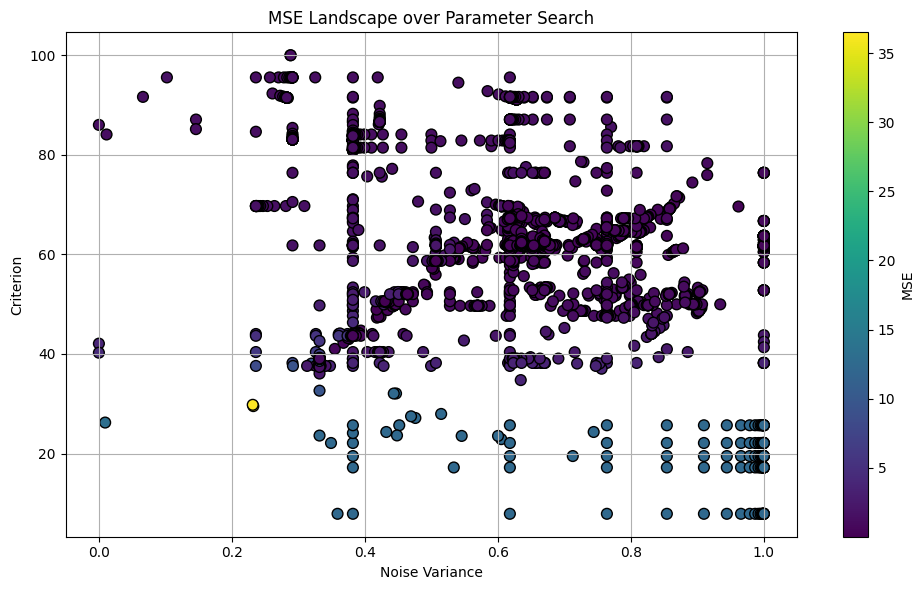

In [26]:
# Convert evaluation log to numpy array for plotting
eval_array = np.array(evaluation_log)
nv = eval_array[:, 0]
crit = eval_array[:, 1]
mse_vals = eval_array[:, 2]

# Scatter plot of all parameter combinations tested
plt.figure(figsize=(10, 6))
sc = plt.scatter(nv, crit, c=mse_vals, cmap='viridis', s=60, edgecolor='k')
plt.colorbar(sc, label='MSE')
plt.xlabel("Noise Variance")
plt.ylabel("Criterion")
plt.title("MSE Landscape over Parameter Search")
plt.grid(True)
plt.tight_layout()
plt.show()